
# Notebook — Modelos AR y MA

## Objetivo
1. Ejecutar un ejemplo de modelo AR y MA.
2. Programar manualmente un modelo AR(1).
3. Programar manualmente un modelo MA(1).

Trabaja paso a paso.


## 1. Librerías

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 2. Datos de serie de tiempo

In [2]:

data = [10,12,13,15,14,16,18,17,19,20,21,19,22,23]

df = pd.DataFrame({"y": data})
df


,y
0,10
1,12
2,13
3,15
4,14
5,16
6,18
7,17
8,19
9,20


## 3. Visualización

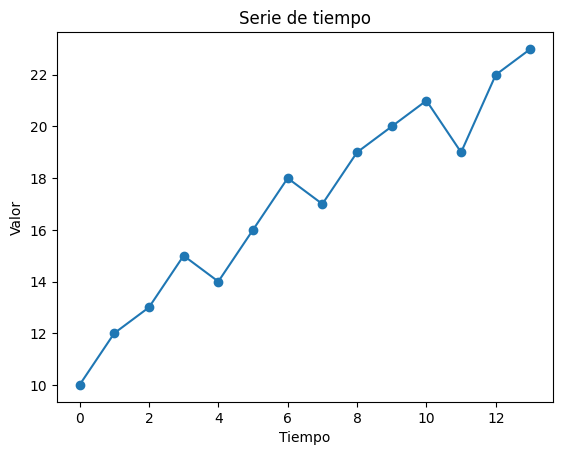

In [3]:

plt.plot(df["y"], marker='o')
plt.title("Serie de tiempo")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.show()



## 4. Ejemplo AUTOMÁTICO (referencia)

Aquí solo observas, no programas.


,y_real,y_pred_ar
0,12,10.0
1,13,11.6
2,15,12.4
3,14,14.0
4,16,13.2
5,18,14.8
6,17,16.4
7,19,15.6
8,20,17.2
9,21,18.0


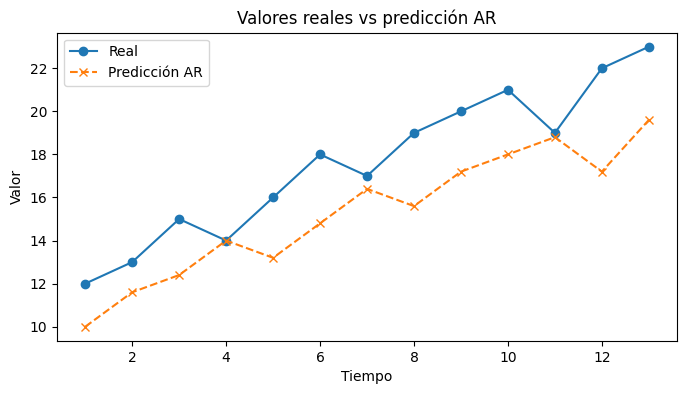

In [7]:
# Modelo AR simple usando numpy (aproximación)
y = df["y"].values

phi = 0.8
c = 2

preds = []
for i in range(1, len(y)):
    preds.append(c + phi * y[i-1])

# Tabla comparativa (valor real vs valor predicho)
df_comp = pd.DataFrame({
    "y_real": y[1:],
    "y_pred_ar": preds
})
display(df_comp)

# Visualización superpuesta
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(y)), y[1:], marker='o', label='Real')
plt.plot(range(1, len(y)), preds, marker='x', linestyle='--', label='Predicción AR')
plt.title("Valores reales vs predicción AR")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()


### Reflexión
1. ¿El modelo sigue la tendencia?
> Sí
2. ¿Qué parámetro controla la influencia del pasado?
> phi


# 5. Tu turno — Modelo AR(1)

Implementa:

y_t = c + φ * y_(t-1)


,y_real,y_pred_ar
0,12,13.0
1,13,14.8
2,15,15.7
3,14,17.5
4,16,16.6
5,18,18.4
6,17,20.2
7,19,19.3
8,20,21.1
9,21,22.0


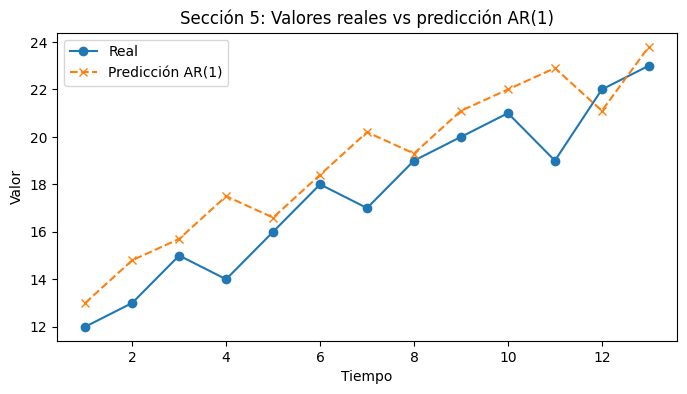

In [11]:
# Completa el modelo AR

phi = 0.9
c = 4

y = df["y"].values

preds_ar = []

for i in range(1, len(y)):
    pred = c + phi * y[i-1]
    preds_ar.append(pred)

# Tabla comparativa (valor real vs valor predicho)
df_comp_ar = pd.DataFrame({
    "y_real": y[1:],
    "y_pred_ar": preds_ar
})
display(df_comp_ar)

# Visualización superpuesta
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(y)), y[1:], marker='o', label='Real')
plt.plot(range(1, len(y)), preds_ar, marker='x', linestyle='--', label='Predicción AR(1)')
plt.title("Sección 5: Valores reales vs predicción AR(1)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()


### Preguntas
- ¿Qué pasa si aumentas φ?
> Se vuelven más agresivos los cambios
- ¿Qué pasa si c cambia?
> Cambía la altura de todo



# 6. Tu turno — Modelo MA(1)

y_t = μ + θ * e_(t-1)

Primero calcula errores manualmente:


,y_real,y_pred_ma
0,12,15.000000
1,13,12.150000
2,15,15.807500
3,14,14.232875
4,16,14.778769
5,18,16.160170
6,17,16.747839
7,19,15.239553
8,20,18.572425
9,21,16.356197


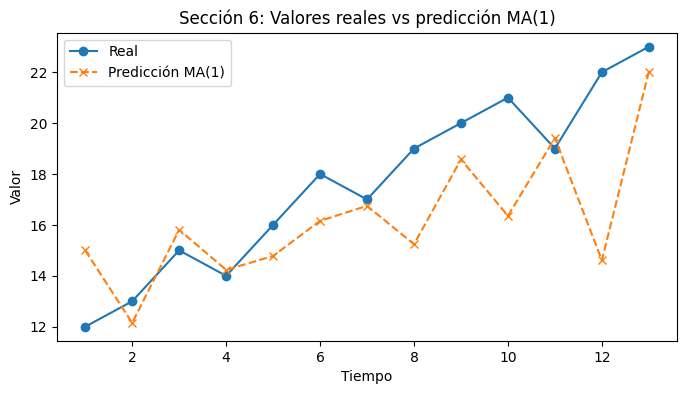

In [15]:
# Inicializa

mu = 15
theta = 0.95

y = df["y"].values

errors = [0]  # error inicial

preds_ma = []

for i in range(1, len(y)):
    pred = mu + theta * errors[i-1]
    error = y[i] - pred

    preds_ma.append(pred)
    errors.append(error)

# Tabla comparativa (valor real vs valor predicho)
df_comp_ma = pd.DataFrame({
    "y_real": y[1:],
    "y_pred_ma": preds_ma
})
display(df_comp_ma)

# Visualización superpuesta
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(y)), y[1:], marker='o', label='Real')
plt.plot(range(1, len(y)), preds_ma, marker='x', linestyle='--', label='Predicción MA(1)')
plt.title("Sección 6: Valores reales vs predicción MA(1)")
plt.xlabel("Tiempo")
plt.ylabel("Valor")
plt.legend()
plt.show()


### Reflexión final

1. ¿Qué modelo fue más fácil de implementar?
> El primero, por que no necesitaba de calcular un error y solo ocupaba un arreglo
2. ¿Qué modelo usa valores reales? ¿Cuál usa errores?
> El primero valores reales, el segundo errores (que para calcularlo se usa valores reales)
3. ¿Cuál crees que se adapta mejor a datos reales?
> El segundo en mi opinión
